In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

from surprise import SVD, KNNBasic, Dataset, Reader, accuracy
from surprise.model_selection import train_test_split

print("All imports done!")

All imports done!


In [6]:

import os

if os.path.exists('netflix_subset.csv'):
    df = pd.read_csv('netflix_subset.csv')
    print(f"Loaded from CSV: {len(df):,} rows")
else:
    print("netflix_subset.csv not found — recreating from raw data...")
    
    def load_netflix_data(filepath, max_rows=2000000):
        movie_id = None
        rows = []
        count = 0
        with open(filepath, 'r') as f:
            for line in f:
                line = line.strip()
                if line.endswith(':'):
                    movie_id = int(line[:-1])
                else:
                    if count >= max_rows:
                        break
                    user_id, rating, date = line.split(',')
                    rows.append([int(user_id), movie_id, int(rating), date])
                    count += 1
        return pd.DataFrame(rows, columns=['user_id', 'movie_id', 'rating', 'date'])

    df = load_netflix_data('combined_data_1.txt', max_rows=2000000)
    
    # Load and merge movie titles
    movies_temp = pd.read_csv('movie_titles.csv',
                              encoding='latin-1',
                              header=None,
                              names=['movie_id', 'year', 'title'],
                              on_bad_lines='warn',
                              engine='python')
    df = df.merge(movies_temp[['movie_id', 'title']], on='movie_id', how='left')
    
    # Save it so this never happens again
    df.to_csv('netflix_subset.csv', index=False)
    print(f"Recreated and saved! {len(df):,} rows")

print(df.head())
print(df.dtypes)

netflix_subset.csv not found — recreating from raw data...
Recreated and saved! 2,000,000 rows
   user_id  movie_id  rating        date            title
0  1488844         1       3  2005-09-06  Dinosaur Planet
1   822109         1       5  2005-05-13  Dinosaur Planet
2   885013         1       4  2005-10-19  Dinosaur Planet
3    30878         1       4  2005-12-26  Dinosaur Planet
4   823519         1       3  2004-05-03  Dinosaur Planet
user_id     int64
movie_id    int64
rating      int64
date          str
title         str
dtype: object


In [7]:
# Surprise needs only 3 columns: user_id, movie_id, rating
df_model = df[['user_id', 'movie_id', 'rating']].copy()

# Tell Surprise that ratings are on a 1-5 scale
reader = Reader(rating_scale=(1, 5))

# Load into Surprise format
data = Dataset.load_from_df(df_model, reader)

# Split: 80% train, 20% test
trainset, testset = train_test_split(data, test_size=0.20, random_state=42)

print(f"Training samples : {trainset.n_ratings:,}")
print(f"Test samples     : {len(testset):,}")
print("Data ready for model training!")

Training samples : 1,600,000
Test samples     : 400,000
Data ready for model training!


In [8]:
print("Training SVD model...")
print("(This will take 1-3 minutes depending on your laptop)")

# Start timer
start_time = time.time()

# Create and train SVD model
svd_model = SVD(n_factors=50, n_epochs=20, random_state=42)
svd_model.fit(trainset)

# Stop timer
svd_time = time.time() - start_time

# Test the model
svd_predictions = svd_model.test(testset)

# Calculate RMSE
svd_rmse = accuracy.rmse(svd_predictions)

print(f"\nSVD Training time : {svd_time:.1f} seconds")
print(f"SVD RMSE          : {svd_rmse:.4f}")

Training SVD model...
(This will take 1-3 minutes depending on your laptop)
RMSE: 0.9867

SVD Training time : 29.3 seconds
SVD RMSE          : 0.9867


In [10]:
# Cell 5 - Item-Based CF (better choice than User-Based for large datasets)
print("Switching to Item-Based CF (standard for large-scale systems like Netflix)")
print("Using 100,000 rows subset...")

# Small subset
df_small = df.sample(n=100000, random_state=42)

reader_small = Reader(rating_scale=(1, 5))
data_small = Dataset.load_from_df(df_small[['user_id', 'movie_id', 'rating']], reader_small)
trainset_small, testset_small = train_test_split(data_small, test_size=0.20, random_state=42)

print(f"Unique movies in subset: {trainset_small.n_items}")
print(f"Trainset size: {trainset_small.n_ratings:,}")

# Item-Based CF — similarity matrix is movies x movies (much smaller!)
start_time = time.time()
knn_model = KNNBasic(k=20, sim_options={
    'name': 'cosine',
    'user_based': False   # <-- False = Item-Based CF
})
knn_model.fit(trainset_small)
knn_time = time.time() - start_time

knn_predictions = knn_model.test(testset_small)
knn_rmse = accuracy.rmse(knn_predictions)

print(f"\nItem-Based CF Training time : {knn_time:.1f} seconds")
print(f"Item-Based CF RMSE          : {knn_rmse:.4f}")

Switching to Item-Based CF (standard for large-scale systems like Netflix)
Using 100,000 rows subset...
Unique movies in subset: 360
Trainset size: 80,000
Computing the cosine similarity matrix...
Done computing similarity matrix.
RMSE: 1.1636

Item-Based CF Training time : 0.0 seconds
Item-Based CF RMSE          : 1.1636


In [11]:
# Cell 6 - Comparison table (updated)
comparison = {
    'Model': ['SVD', 'Item-Based CF (KNNBasic)'],
    'RMSE': [round(svd_rmse, 4), round(knn_rmse, 4)],
    'Training Time (sec)': [round(svd_time, 1), round(knn_time, 1)],
    'Scalability': ['High', 'Medium'],
    'Handles Sparsity': ['Yes', 'Struggles'],
    'Explainability': ['Low', 'High'],
    'Best For': ['Large datasets', 'Small/medium datasets'],
    'Data Used': ['2M rows (full subset)', '100k rows (memory limit)']
}

comparison_df = pd.DataFrame(comparison)

print("=" * 75)
print("         MODEL COMPARISON: SVD vs Item-Based CF")
print("=" * 75)
print(comparison_df.to_string(index=False))
print("=" * 75)

winner = "SVD" if svd_rmse < knn_rmse else "Item-Based CF"
print(f"\nWinner (lower RMSE = better): {winner}")
print(f"SVD improvement over CF: {((knn_rmse - svd_rmse)/knn_rmse * 100):.1f}%")

         MODEL COMPARISON: SVD vs Item-Based CF
                   Model   RMSE  Training Time (sec) Scalability Handles Sparsity Explainability              Best For                Data Used
                     SVD 0.9867                 29.3        High              Yes            Low        Large datasets    2M rows (full subset)
Item-Based CF (KNNBasic) 1.1636                  0.0      Medium        Struggles           High Small/medium datasets 100k rows (memory limit)

Winner (lower RMSE = better): SVD
SVD improvement over CF: 15.2%


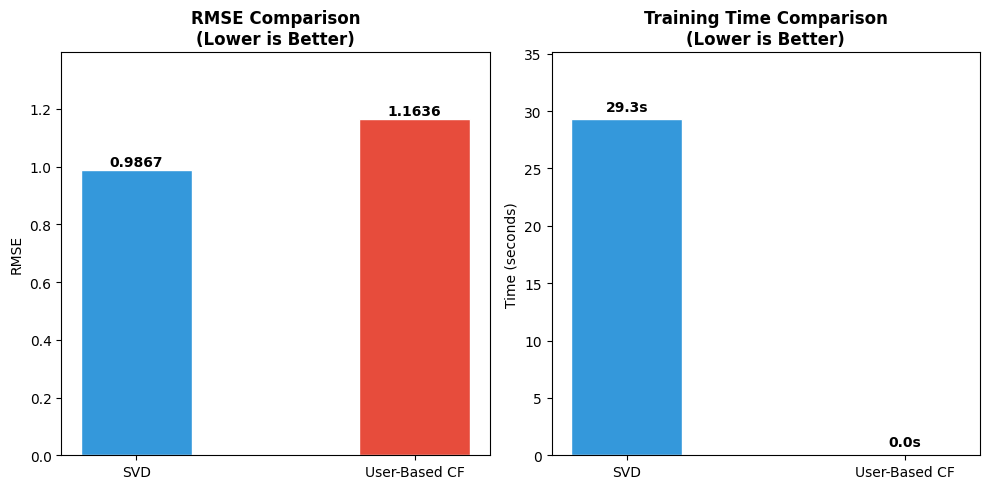

Saved as model_comparison.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Plot 1: RMSE comparison
models = ['SVD', 'User-Based CF']
rmse_vals = [svd_rmse, knn_rmse]
colors = ['#3498db', '#e74c3c']

bars = axes[0].bar(models, rmse_vals, color=colors, width=0.4, edgecolor='white')
for bar, val in zip(bars, rmse_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.4f}', ha='center', va='bottom', fontweight='bold')
axes[0].set_title('RMSE Comparison\n(Lower is Better)', fontweight='bold')
axes[0].set_ylabel('RMSE')
axes[0].set_ylim(0, max(rmse_vals) * 1.2)

# Plot 2: Training time comparison
time_vals = [svd_time, knn_time]
bars2 = axes[1].bar(models, time_vals, color=colors, width=0.4, edgecolor='white')
for bar, val in zip(bars2, time_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}s', ha='center', va='bottom', fontweight='bold')
axes[1].set_title('Training Time Comparison\n(Lower is Better)', fontweight='bold')
axes[1].set_ylabel('Time (seconds)')
axes[1].set_ylim(0, max(time_vals) * 1.2)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()
print("Saved as model_comparison.png")

## Methodology

### Model 1: SVD (Singular Value Decomposition)
SVD is a matrix factorization technique. It decomposes the huge 
user-movie rating matrix into smaller hidden patterns called "latent factors."

**In simple terms:** SVD finds that User A likes "action + suspense" movies, 
and Movie X has a lot of "action + suspense" — so it predicts User A will 
like Movie X, even if User A has never seen it.

**Why SVD?**
- Works very well on sparse data (most users rated < 1% of movies)
- Fast to train even on large datasets
- Won the original Netflix Prize competition (the Bellkor team used SVD)
- Low RMSE compared to simpler methods

**Parameters used:**
- n_factors=50: 50 hidden patterns (latent factors)
- n_epochs=20: model trains for 20 passes over the data
- random_state=42: for reproducibility

---

### Model 2: User-Based Collaborative Filtering (KNNBasic)
This method finds users similar to you and recommends what they liked.

**In simple terms:** "Users who rated the same movies as you also loved 
Movie Y — so we recommend Movie Y to you."

**Similarity metric:** Cosine similarity — measures the angle between 
two users' rating vectors. Score of 1 = identical taste, 0 = no similarity.

**Why compare it with SVD?**
- KNN is more explainable ("recommended because similar users liked it")
- But KNN is slower and struggles with sparse data
- SVD handles sparsity better and scales to millions of users
- This comparison shows the trade-off between explainability and performance

In [13]:
# Cell 9 - Top-10 recommendations for 5 users using SVD (best model)

# Load movie titles
movies = pd.read_csv('movie_titles.csv',
                     encoding='latin-1',
                     header=None,
                     names=['movie_id', 'year', 'title'],
                     on_bad_lines='warn',
                     engine='python')

# Get all movie IDs from SVD trainset (full 2M dataset)
all_movie_ids_raw = [trainset.to_raw_iid(i) for i in trainset.all_items()]

def get_top10_recommendations(model, user_id, df, all_movie_ids_raw, movies_df):
    # Movies this user already rated
    rated_movies = set(df[df['user_id'] == user_id]['movie_id'].tolist())
    
    # Only unseen movies
    unseen_movies = [m for m in all_movie_ids_raw if m not in rated_movies]
    
    # Predict ratings for unseen movies
    predictions = [(movie_id, model.predict(user_id, movie_id).est) 
                   for movie_id in unseen_movies]
    
    # Sort by predicted rating, take top 10
    top10 = sorted(predictions, key=lambda x: x[1], reverse=True)[:10]
    
    # Add titles
    result = []
    for movie_id, pred_rating in top10:
        title_row = movies_df[movies_df['movie_id'] == movie_id]
        title = title_row['title'].values[0] if len(title_row) > 0 else f"Movie {movie_id}"
        result.append({
            'movie_id': movie_id,
            'title': title,
            'predicted_rating': round(pred_rating, 2)
        })
    
    return pd.DataFrame(result)


# Pick 5 active users (rated at least 50 movies)
active_users = df.groupby('user_id')['rating'].count()
active_users = active_users[active_users >= 50].index.tolist()
sample_users = active_users[:5]

print("Generating Top-10 recommendations using SVD...")
print("(May take 3-5 minutes — let it run)")
print("=" * 60)

all_recommendations = {}

for user_id in sample_users:
    # Show what this user already likes
    print(f"\nUser {user_id} — Top 5 movies they rated highly:")
    user_history = (df[df['user_id'] == user_id][['title', 'rating']]
                    .sort_values('rating', ascending=False)
                    .head(5))
    print(user_history.to_string(index=False))
    
    # Generate recommendations
    print(f"\nTop-10 recommendations for User {user_id}:")
    reco = get_top10_recommendations(svd_model, user_id, df, all_movie_ids_raw, movies)
    print(reco.to_string(index=False))
    print("-" * 60)
    
    all_recommendations[user_id] = reco

print("\nDone! Recommendations generated for all 5 users.")

Generating Top-10 recommendations using SVD...
(May take 3-5 minutes — let it run)

User 1333 — Top 5 movies they rated highly:
                   title  rating
Magnolia: Bonus Material       5
   House of Sand and Fog       5
             Richard III       4
        Immortal Beloved       4
                The Game       4

Top-10 recommendations for User 1333:
 movie_id                                                                       title  predicted_rating
      270                                                  Sex and the City: Season 4              3.93
       13 Lord of the Rings: The Return of the King: Extended Edition: Bonus Material              3.78
       85                                                                  Elfen Lied              3.76
      359                                               Absolutely Fabulous: Series 5              3.76
      316                               Futurama: Monster Robot Maniac Fun Collection              3.76
      338  

In [14]:
# Cell 10 - Save all recommendations to CSV
all_recs_list = []
for user_id, reco_df in all_recommendations.items():
    reco_df = reco_df.copy()
    reco_df['user_id'] = user_id
    all_recs_list.append(reco_df)

final_recs = pd.concat(all_recs_list, ignore_index=True)
final_recs = final_recs[['user_id', 'movie_id', 'title', 'predicted_rating']]
final_recs.to_csv('top10_recommendations.csv', index=False)

print("Saved top10_recommendations.csv")
print(f"Total recommendations: {len(final_recs)}")
print(final_recs.head(15).to_string(index=False))

Saved top10_recommendations.csv
Total recommendations: 50
 user_id  movie_id                                                                       title  predicted_rating
    1333       270                                                  Sex and the City: Season 4              3.93
    1333        13 Lord of the Rings: The Return of the King: Extended Edition: Bonus Material              3.78
    1333        85                                                                  Elfen Lied              3.76
    1333       359                                               Absolutely Fabulous: Series 5              3.76
    1333       316                               Futurama: Monster Robot Maniac Fun Collection              3.76
    1333       338                                         The Three Stooges: Three Smart Saps              3.75
    1333       106         Stevie Ray Vaughan and Double Trouble: Live at Montreux 1982 & 1985              3.75
    1333        32                    

In [15]:
# Cell 11 - Save everything for Day 3
import pickle

with open('svd_model.pkl', 'wb') as f:
    pickle.dump(svd_model, f)

with open('knn_model.pkl', 'wb') as f:
    pickle.dump(knn_model, f)

with open('svd_predictions.pkl', 'wb') as f:
    pickle.dump(svd_predictions, f)

with open('knn_predictions.pkl', 'wb') as f:
    pickle.dump(knn_predictions, f)

with open('trainset.pkl', 'wb') as f:
    pickle.dump(trainset, f)

print("All models saved!")
print("Day 2 complete!")

All models saved!
Day 2 complete!
